# Exploratory Data Analysis — Financial Fraud Detection

This notebook explores the cleaned credit-card transaction dataset before
model development.

Objectives:
- Verify the cleaned dataset
- Analyze fraud class distribution
- Examine transaction amount patterns
- Examine transaction timing patterns
- Compare legitimate and fraudulent transactions
- Analyze anonymized V1–V28 features
- Examine feature correlations with the target
- Identify potential modeling considerations

No resampling, scaling, feature selection, or model training is performed
during this stage.

FINANCIAL FRAUD DETECTION — EXPLORATORY DATA ANALYSIS

Dataset shape     : (283726, 31)
Rows              : 283,726
Columns           : 31
Missing values    : 0
Exact duplicates  : 0

EDA dataset validation passed.

BASIC STATISTICAL SUMMARY

Time range:
0.00 to 172,792.00 seconds

Amount range:
0.00 to 25,691.16

Amount statistics:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

CLASS DISTRIBUTION

Class summary:
        Count  Percentage
Class                    
0      283253    99.83329
1         473     0.16671

Legitimate transactions : 283,253
Fraud transactions      : 473
Fraud rate              : 0.1667%
Imbalance ratio         : 598.84:1


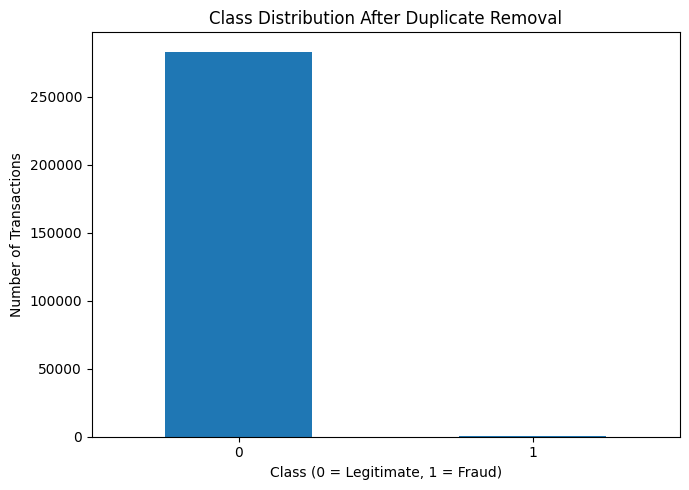


CLASS DATASETS
Legitimate shape : (283253, 31)
Fraud shape      : (473, 31)

TRANSACTION AMOUNT ANALYSIS

Amount comparison:
          Legitimate        Fraud
count  283253.000000   473.000000
mean       88.413575   123.871860
std       250.379023   260.211041
min         0.000000     0.000000
25%         5.670000     1.000000
50%        22.000000     9.820000
75%        77.460000   105.890000
max     25691.160000  2125.870000

Amount percentiles:
     Legitimate      Fraud
25%      5.6700     1.0000
50%     22.0000     9.8200
75%     77.4600   105.8900
90%    203.0000   348.6520
95%    365.0000   655.8200
99%   1018.0576  1364.1368


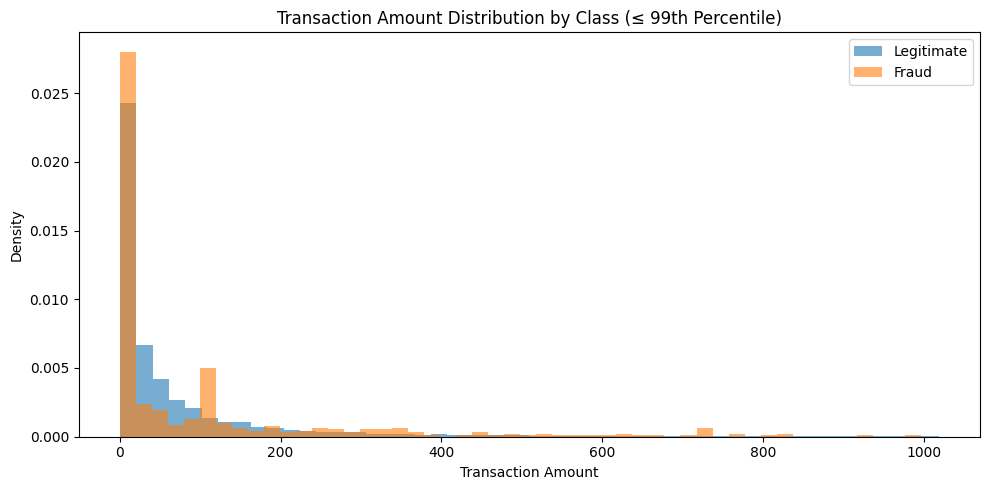

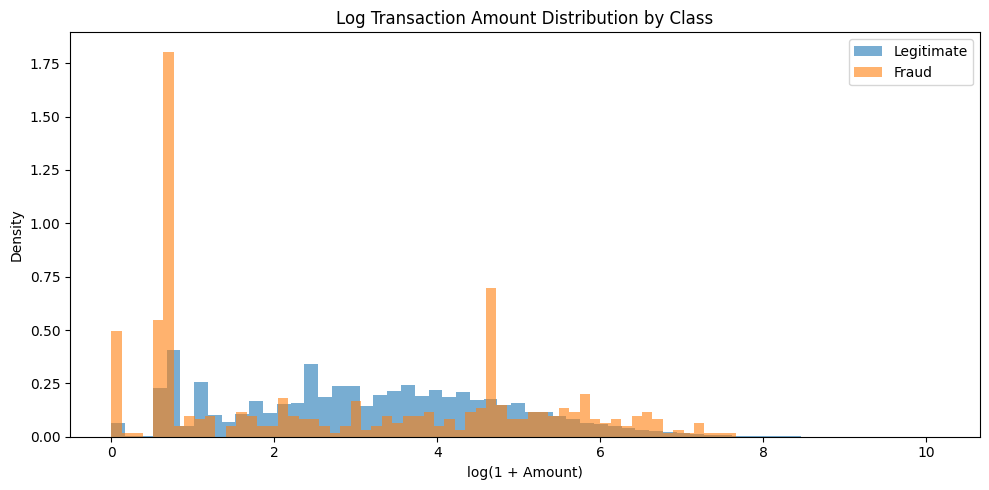


TRANSACTION TIME ANALYSIS

Time comparison:
          Legitimate          Fraud
count  283253.000000     473.000000
mean    94835.058093   80450.513742
std     47475.550607   48636.179973
min         0.000000     406.000000
25%     54233.000000   41203.000000
50%     84711.000000   73408.000000
75%    139308.000000  129095.000000
max    172792.000000  170348.000000


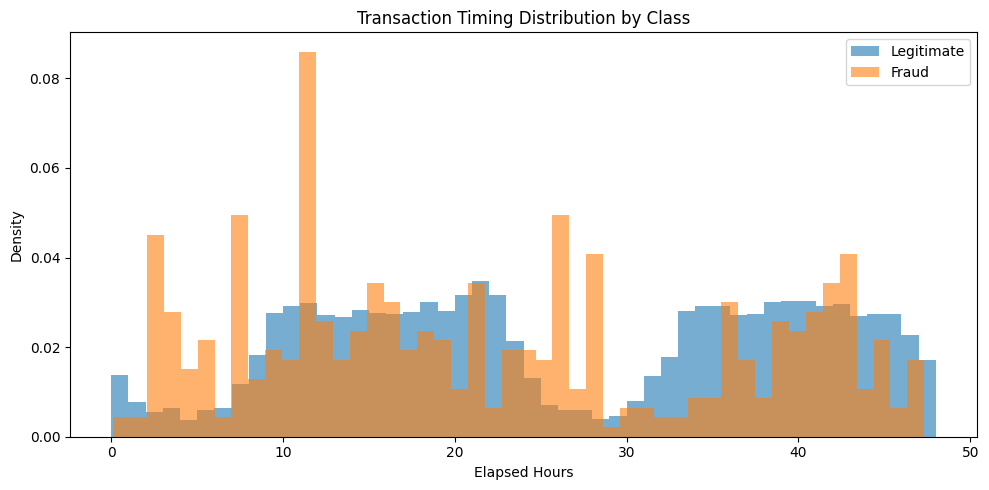


ANONYMIZED FEATURE ANALYSIS

Top 15 V-features by absolute difference in class means:
     Legitimate_Mean  Fraud_Mean  Mean_Difference  Absolute_Mean_Difference
V14         0.011668   -6.835946        -6.847614                  6.847614
V3          0.012853   -6.729599        -6.742452                  6.742452
V17         0.010963   -6.463285        -6.474249                  6.474249
V12         0.009476   -6.103254        -6.112730                  6.112730
V10         0.007663   -5.453274        -5.460937                  5.460937
V7          0.010447   -5.175912        -5.186359                  5.186359
V1          0.013439   -4.498280        -4.511719                  4.511719
V4         -0.010440    4.472591         4.483031                  4.483031
V16         0.007845   -4.000956        -4.008801                  4.008801
V11        -0.006004    3.716347         3.722350                  3.722350
V2         -0.009829    3.405965         3.415794                  3.415794
V

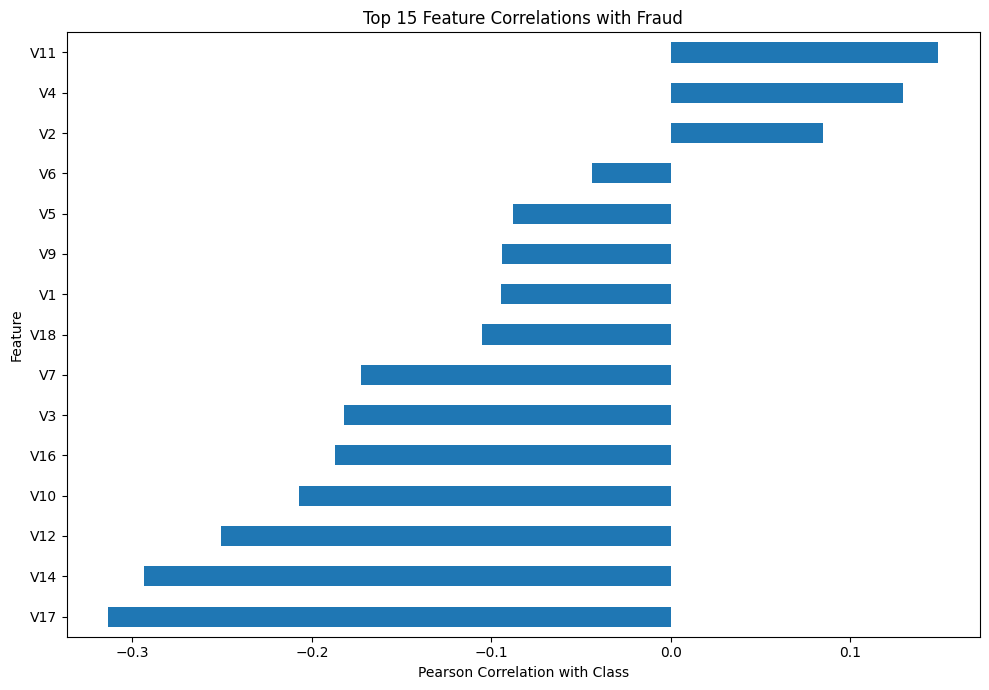

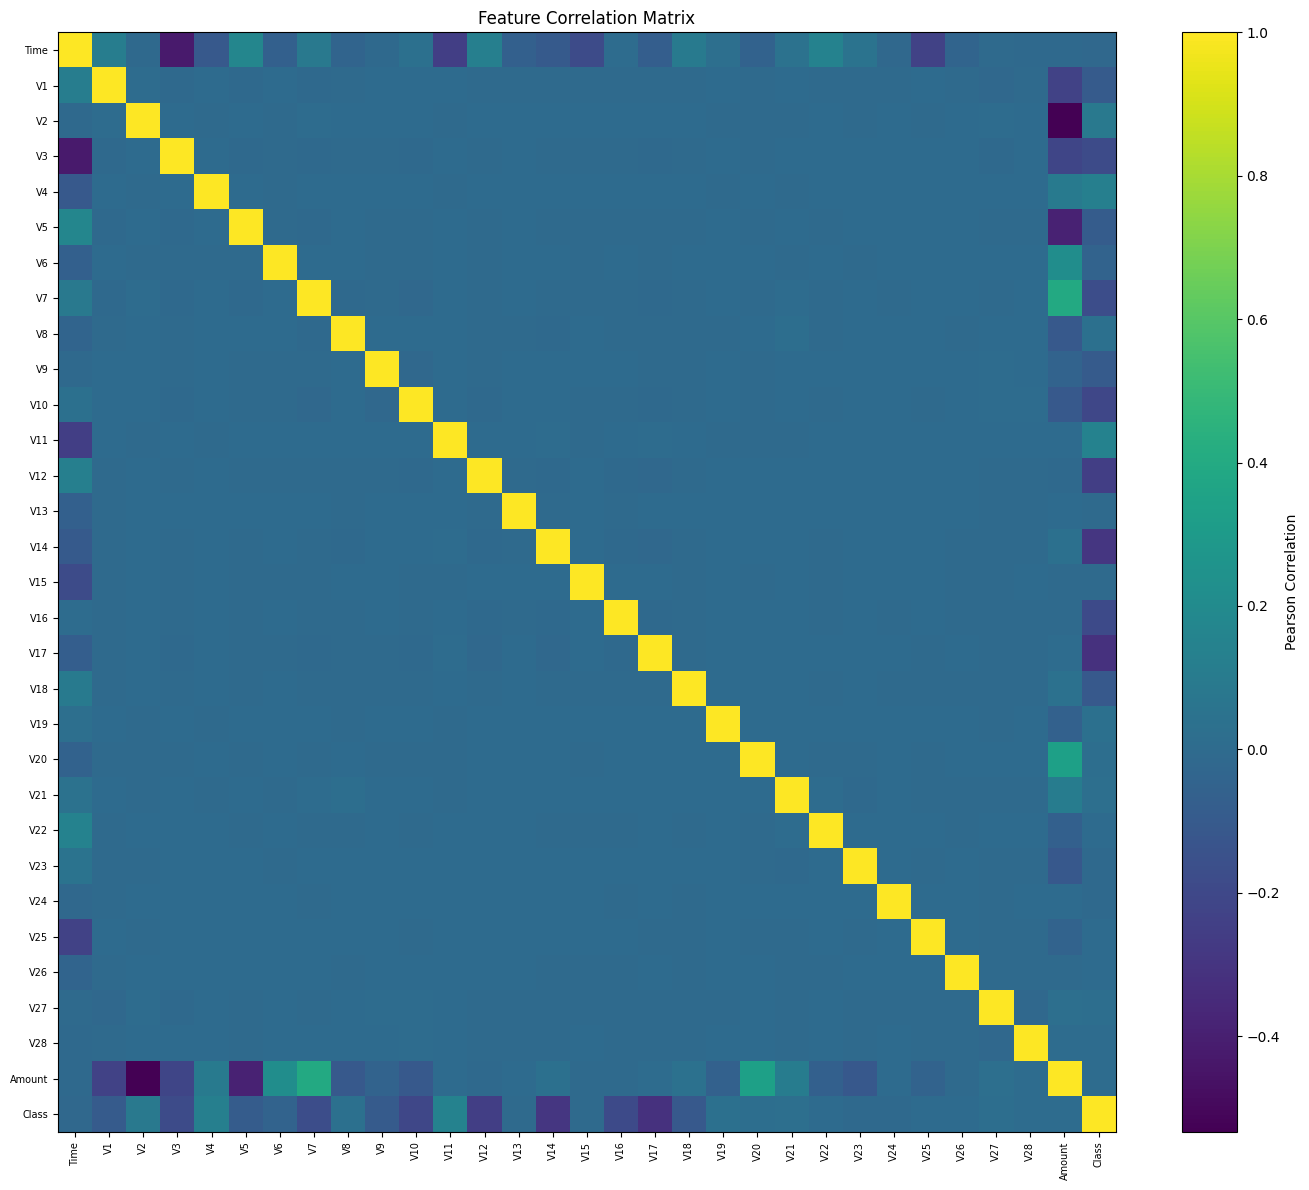


FINAL EDA SUMMARY
Total rows                    : 283,726
Total features                : 30
Legitimate transactions       : 283,253
Fraud transactions            : 473
Fraud rate (%)                : 0.1667
Imbalance ratio               : 598.8436
Missing values                : 0
Exact duplicates              : 0
Overall median amount         : 22.0000
Legitimate median amount      : 22.0000
Fraud median amount           : 9.8200
Maximum amount                : 25,691.1600

MODELING CONSIDERATIONS IDENTIFIED DURING EDA

1. The target variable is extremely imbalanced.
   Accuracy alone will therefore be misleading.

2. Precision, recall, F1-score, PR-AUC and confusion
   matrices will be important evaluation metrics.

3. Transaction Amount is strongly skewed and contains
   extreme values.

4. Scaling decisions for Amount and Time must be learned
   using training data only.

5. V1-V28 are anonymized numerical features. Their original
   semantic meanings must not be invented.

6. Co

In [103]:
# ============================================================
# TASK 5 — EXPLORATORY DATA ANALYSIS (EDA)
# Financial Fraud Detection Project
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD CLEANED DATA
# ============================================================

DATA_PATH = Path("../../data/processed/creditcard_cleaned.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("FINANCIAL FRAUD DETECTION — EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print(f"\nDataset shape     : {df.shape}")
print(f"Rows              : {len(df):,}")
print(f"Columns           : {df.shape[1]}")
print(f"Missing values    : {df.isna().sum().sum():,}")
print(f"Exact duplicates  : {df.duplicated().sum():,}")


# ============================================================
# 2. BASIC DATA VALIDATION
# ============================================================

required_columns = (
    ["Time"]
    + [f"V{i}" for i in range(1, 29)]
    + ["Amount", "Class"]
)

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

if df.isna().sum().sum() != 0:
    raise ValueError("Dataset contains missing values.")

if df.duplicated().sum() != 0:
    raise ValueError("Dataset still contains duplicate rows.")

if not set(df["Class"].unique()).issubset({0, 1}):
    raise ValueError("Class must contain only 0 and 1.")

print("\nEDA dataset validation passed.")


# ============================================================
# 3. BASIC STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("BASIC STATISTICAL SUMMARY")
print("=" * 70)

print("\nTime range:")
print(
    f"{df['Time'].min():,.2f} "
    f"to {df['Time'].max():,.2f} seconds"
)

print("\nAmount range:")
print(
    f"{df['Amount'].min():,.2f} "
    f"to {df['Amount'].max():,.2f}"
)

print("\nAmount statistics:")
print(df["Amount"].describe())


# ============================================================
# 4. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

class_counts = (
    df["Class"]
    .value_counts()
    .sort_index()
)

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

print("\nClass summary:")
print(class_summary)

legitimate_count = int(class_counts.get(0, 0))
fraud_count = int(class_counts.get(1, 0))

if fraud_count == 0:
    raise ValueError("No fraud observations found.")

imbalance_ratio = legitimate_count / fraud_count

print(
    f"\nLegitimate transactions : "
    f"{legitimate_count:,}"
)

print(
    f"Fraud transactions      : "
    f"{fraud_count:,}"
)

print(
    f"Fraud rate              : "
    f"{class_percentages.loc[1]:.4f}%"
)

print(
    f"Imbalance ratio         : "
    f"{imbalance_ratio:.2f}:1"
)


# ============================================================
# 5. CLASS DISTRIBUTION PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

class_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Class Distribution After Duplicate Removal"
)

ax.set_xlabel(
    "Class (0 = Legitimate, 1 = Fraud)"
)

ax.set_ylabel(
    "Number of Transactions"
)

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. CREATE CLASS-SPECIFIC DATAFRAMES
# ============================================================

legitimate = (
    df.loc[df["Class"] == 0]
    .copy()
)

fraud = (
    df.loc[df["Class"] == 1]
    .copy()
)

print("\n" + "=" * 70)
print("CLASS DATASETS")
print("=" * 70)

print(
    f"Legitimate shape : {legitimate.shape}"
)

print(
    f"Fraud shape      : {fraud.shape}"
)


# ============================================================
# 7. TRANSACTION AMOUNT COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 70)

amount_comparison = pd.DataFrame({
    "Legitimate":
        legitimate["Amount"].describe(),

    "Fraud":
        fraud["Amount"].describe()
})

print("\nAmount comparison:")
print(amount_comparison)


# ============================================================
# 8. AMOUNT PERCENTILES
# ============================================================

percentiles = [
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]

amount_percentiles = pd.DataFrame({
    "Legitimate":
        legitimate["Amount"].quantile(percentiles),

    "Fraud":
        fraud["Amount"].quantile(percentiles)
})

amount_percentiles.index = [
    "25%",
    "50%",
    "75%",
    "90%",
    "95%",
    "99%"
]

print("\nAmount percentiles:")
print(amount_percentiles)


# ============================================================
# 9. AMOUNT DISTRIBUTION
# ============================================================

# Restrict visualization to the 99th percentile so that
# extreme transaction amounts do not dominate the graph.

amount_plot_limit = df["Amount"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    legitimate.loc[
        legitimate["Amount"] <= amount_plot_limit,
        "Amount"
    ],
    bins=50,
    density=True,
    alpha=0.6,
    label="Legitimate"
)

ax.hist(
    fraud.loc[
        fraud["Amount"] <= amount_plot_limit,
        "Amount"
    ],
    bins=50,
    density=True,
    alpha=0.6,
    label="Fraud"
)

ax.set_title(
    "Transaction Amount Distribution by Class "
    "(≤ 99th Percentile)"
)

ax.set_xlabel(
    "Transaction Amount"
)

ax.set_ylabel(
    "Density"
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 10. LOG-AMOUNT DISTRIBUTION
# ============================================================

# Temporary variable used only for EDA visualization.
# It does NOT modify the modeling dataset.

log_legitimate_amount = np.log1p(
    legitimate["Amount"]
)

log_fraud_amount = np.log1p(
    fraud["Amount"]
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    log_legitimate_amount,
    bins=60,
    density=True,
    alpha=0.6,
    label="Legitimate"
)

ax.hist(
    log_fraud_amount,
    bins=60,
    density=True,
    alpha=0.6,
    label="Fraud"
)

ax.set_title(
    "Log Transaction Amount Distribution by Class"
)

ax.set_xlabel(
    "log(1 + Amount)"
)

ax.set_ylabel(
    "Density"
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. TIME ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TRANSACTION TIME ANALYSIS")
print("=" * 70)

time_comparison = pd.DataFrame({
    "Legitimate":
        legitimate["Time"].describe(),

    "Fraud":
        fraud["Time"].describe()
})

print("\nTime comparison:")
print(time_comparison)


# Convert elapsed seconds to elapsed hours for visualization.
# This is NOT interpreted as clock time.

legitimate_hours = (
    legitimate["Time"] / 3600
)

fraud_hours = (
    fraud["Time"] / 3600
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    legitimate_hours,
    bins=48,
    density=True,
    alpha=0.6,
    label="Legitimate"
)

ax.hist(
    fraud_hours,
    bins=48,
    density=True,
    alpha=0.6,
    label="Fraud"
)

ax.set_title(
    "Transaction Timing Distribution by Class"
)

ax.set_xlabel(
    "Elapsed Hours"
)

ax.set_ylabel(
    "Density"
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 12. V1–V28 FEATURE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("ANONYMIZED FEATURE ANALYSIS")
print("=" * 70)

v_columns = [
    f"V{i}"
    for i in range(1, 29)
]

v_class_means = (
    df.groupby("Class")[v_columns]
    .mean()
    .T
)

v_class_means.columns = [
    "Legitimate_Mean",
    "Fraud_Mean"
]

v_class_means["Mean_Difference"] = (
    v_class_means["Fraud_Mean"]
    - v_class_means["Legitimate_Mean"]
)

v_class_means["Absolute_Mean_Difference"] = (
    v_class_means["Mean_Difference"]
    .abs()
)

v_class_means = (
    v_class_means
    .sort_values(
        "Absolute_Mean_Difference",
        ascending=False
    )
)

print(
    "\nTop 15 V-features by absolute "
    "difference in class means:"
)

print(
    v_class_means.head(15)
)


# ============================================================
# 13. FEATURE CORRELATION WITH TARGET
# ============================================================

correlations = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
)

correlation_table = pd.DataFrame({
    "Correlation":
        correlations,

    "Absolute_Correlation":
        correlations.abs()
})

correlation_table = (
    correlation_table
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

print("\nTop 15 absolute correlations with fraud:")

print(
    correlation_table.head(15)
)


# ============================================================
# 14. CORRELATION PLOT
# ============================================================

top_15_correlations = (
    correlation_table
    .head(15)
    .sort_values("Correlation")
)

fig, ax = plt.subplots(figsize=(10, 7))

top_15_correlations["Correlation"].plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "Top 15 Feature Correlations with Fraud"
)

ax.set_xlabel(
    "Pearson Correlation with Class"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. CORRELATION MATRIX
# ============================================================

# Full numerical correlation matrix.
# This is exploratory only; we are NOT removing features.

correlation_matrix = (
    df.corr(numeric_only=True)
)

fig, ax = plt.subplots(
    figsize=(14, 12)
)

image = ax.imshow(
    correlation_matrix,
    aspect="auto"
)

ax.set_title(
    "Feature Correlation Matrix"
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
    fontsize=7
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(
    correlation_matrix.index,
    fontsize=7
)

fig.colorbar(
    image,
    ax=ax,
    label="Pearson Correlation"
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. FINAL EDA SUMMARY
# ============================================================

eda_summary = {
    "Total rows":
        len(df),

    "Total features":
        df.shape[1] - 1,

    "Legitimate transactions":
        legitimate_count,

    "Fraud transactions":
        fraud_count,

    "Fraud rate (%)":
        float(
            class_percentages.loc[1]
        ),

    "Imbalance ratio":
        float(
            imbalance_ratio
        ),

    "Missing values":
        int(
            df.isna().sum().sum()
        ),

    "Exact duplicates":
        int(
            df.duplicated().sum()
        ),

    "Overall median amount":
        float(
            df["Amount"].median()
        ),

    "Legitimate median amount":
        float(
            legitimate["Amount"].median()
        ),

    "Fraud median amount":
        float(
            fraud["Amount"].median()
        ),

    "Maximum amount":
        float(
            df["Amount"].max()
        )
}


print("\n" + "=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

for key, value in eda_summary.items():

    if isinstance(value, float):
        print(
            f"{key:<30}: {value:,.4f}"
        )

    else:
        print(
            f"{key:<30}: {value:,}"
        )


# ============================================================
# 17. MODELING CONSIDERATIONS
# ============================================================

print("\n" + "=" * 70)
print("MODELING CONSIDERATIONS IDENTIFIED DURING EDA")
print("=" * 70)

print("""
1. The target variable is extremely imbalanced.
   Accuracy alone will therefore be misleading.

2. Precision, recall, F1-score, PR-AUC and confusion
   matrices will be important evaluation metrics.

3. Transaction Amount is strongly skewed and contains
   extreme values.

4. Scaling decisions for Amount and Time must be learned
   using training data only.

5. V1-V28 are anonymized numerical features. Their original
   semantic meanings must not be invented.

6. Correlation analysis is exploratory only. Features will
   not be removed solely because of low Pearson correlation.

7. No SMOTE, scaling, threshold optimization, or model
   fitting has been performed during EDA.

8. Dataset splitting must occur before fitting any
   preprocessing transformations.
""")


print("=" * 70)
print("TASK 5 — EDA COMPLETED")
print("=" * 70)